<a href="https://colab.research.google.com/github/GabrielLRizzo/Atividade_01/blob/main/solucao/atividade_01_247111.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade 01 - Classificação Linear

Como primeira atividade entregável da disciplina, vamos aplicar o modelo de regressão logística ao problema de classificar espécimes de cogumelos como comestíveis ou venenosos.

Para isso, vamos utilizar o *dataset* disponível no UCI Machine Learning Repository: https://doi.org/10.24432/C5959T

![](https://storage.googleapis.com/kaggle-datasets-images/478/974/557711140aeab7ca242d1e903c4e058e/dataset-cover.jpg)

Este *dataset* apresenta pelo menos duas peculiaridades:
* Atributos categóricos: símbolos ou *strings* indicam as possibilidades para certas características de um cogumelo.
Por exemplo, o atributo `cap_shape` (forma do chapéu) pode ser: sino (b), cônico (c), convexo (x), plano (f), afundado (s) nodoso (k).
* Atributos faltantes: algumas amostras não possuem valores para todos os atributos.


## Preâmbulo: Carregando o *dataset* (arquivo .csv) para o Drive



In [18]:
""" Carregando o dataset do Github para trabalhar autonomamente no Colab """

import requests
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score, classification_report,f1_score, roc_curve, auc, RocCurveDisplay

# Caminho para a pasta que conterá o dataset
data_path = Path("data/")

# Se o diretório ainda não existe, criamos e baixamos o dataset
if data_path.is_dir():
    print(f"O diretório {data_path} já existe")
else:
    print(f"Diretório {data_path} não localizado, criando um ...")
    data_path.mkdir(parents=True, exist_ok=True)

    with open(data_path / "mushroom.csv", "wb") as f:
        request = requests.get("https://github.com/EA991-Lab/utils/raw/main/data/mushrooms.csv")
        print("Baixando os dados ...")
        f.write(request.content)

O diretório data já existe


Com isso, o arquivo de dados estará disponível no Drive para uso através do caminho "data/mushrooms.csv".


## Parte 1: Análise dos dados

a) Faça uma breve descrição do *dataset*, apontando quantidade de amostras, de atributos (*features*), valores possíveis para cada atributo etc.

b) Trabalhando com o *dataset* na forma de um `Pandas.DataFrame`, obtenha uma visão geral de suas características (ver método `describe()`), avalie o balanceamento entre as classes e mostre os histogramas por atributo. Faça uma discussão geral desses pontos.

c) Existe algum atributo claramente irrelevante para a tarefa? Se sim, por quê?

Parte 1: 

a) Dataset: 

Número de amostras: 8124
Número de atributos: 22 (mais o target 'class')

Tabela das primeiras 5 amostras:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g



Valores de cada atributo:

• class (2 valores): ['e', 'p']

• cap-shape (6 valores): ['b', 'c', 'f', 'k', 's', 'x']

• cap-surface (4 valores): ['f', 'g', 's', 'y']

• cap-color (10 valores): ['b', 'c', 'e', 'g', 'n', 'p', 'r', 'u', 'w', 'y']

• bruises (2 valores): ['f', 't']

• odor (9 valores): ['a', 'c', 'f', 'l', 'm', 'n', 'p', 's', 'y']

• gill-attachment (2 valores): ['a', 'f']

• gill-spacing (2 valores): ['c', 'w']

• gill-size (2 valores): ['b', 'n']

• gill-color (12 valores): ['b', 'e', 'g', 'h', 'k', 'n', 'o', 'p', 'r', 'u', 'w', 'y']

• stalk-shape (2 valores): ['e', 't']

• stalk-root (5 valores): ['?', 'b', 'c', 'e', 'r']

• stalk-surface-above-ring (4 valores): ['f', 'k', 's', 'y']

• stalk-surface-below-ring (4 valores): ['f', 'k', 's', 'y']

• stalk-color-above-ring (9 valores): ['b', 'c', 'e', 'g', 'n', 'o', 'p', 'w', 'y']

• stalk-color-below-ring (9 valores): ['b', 'c', 'e', 'g', 'n', 'o', 'p', 'w', 'y']

• veil-type (1 valores): ['p']

• veil-color (4 valores): 

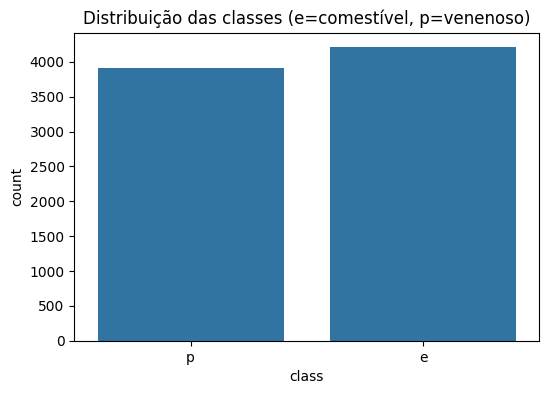

Colunas no DataFrame: ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


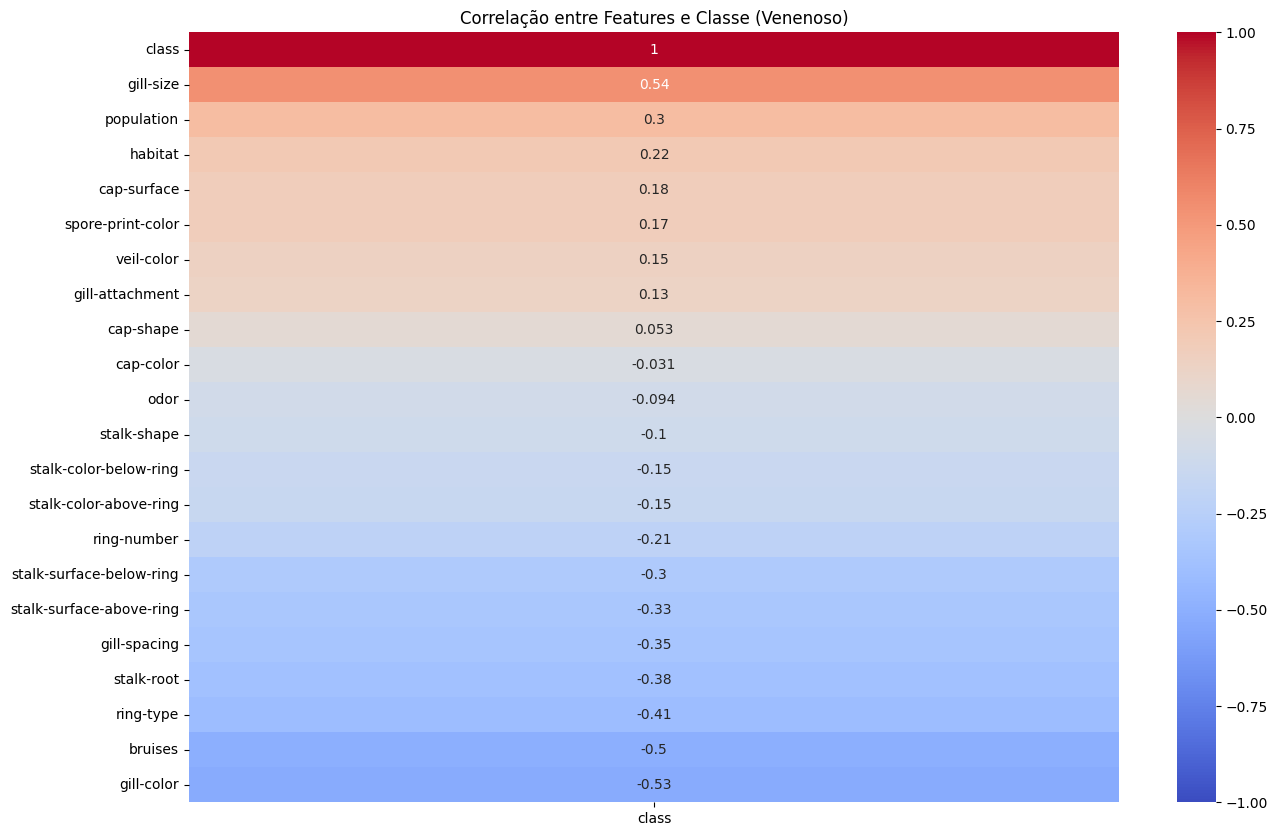

In [19]:
#a) Descrição do dataset (Quantidade de amostras, features e seus valores)
df = pd.read_csv(data_path / "mushroom.csv")
print("Parte 1: \n")
print("a) Dataset: \n")
print(f"Número de amostras: {df.shape[0]}")
print(f"Número de atributos: {df.shape[1] - 1} (mais o target 'class')\n")
print("Tabela das primeiras 5 amostras:")
display(df.head())
print("\nValores de cada atributo:")
for x in df.columns:
    valores = df[x].unique()
    print(f"\n• {x} ({len(valores)} valores): {sorted(valores)}")

#b) Visão Geral
print("\n")
print(df.describe())

print("\nBalanceamento das classes:")
print("Colunas:", df.columns.tolist())
print(df['class'].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='class')
plt.title('Distribuição das classes (e=comestível, p=venenoso)')
plt.show()

''' Se observa que os dados são bem equilibrados, é quase 50-50 (cogumelos comestíveis e venenosos)
    o que é bom para o aprendizado da máquina, uma vez que tendo proporção parecida, existe uma boa chance
    do X_treino também não ter viés, que por sua vez, minimiza as chances da máquina não reconhecer uma das
    classes por falta de exemplos nos dados de entrada separados para treino. Além disso, isso garante que a Acurácia
    (que é muito sensível ao desbalanceamento) fica menos enviesada, e maior a Acurácia Balanceada. '''

''' O gráfico está logo em seguida, ao descartar atributos irrelevantes. Siga o (*)'''


# c) Atributos Irrelevantes

''' O atributo veil-type possui apenas um valor possível ('p'), o que significa que ele não é tão útil para ser utilizado como parâmetro
    para diferenciar/classificar os cogumelos entre comestíveis e venenosos, pois todos tem esse atributo. Logo, é irrelevante considerá-lo
    como informação a ser passada na aprendizagem da máquina, pois não contribui para diferenciar os dados '''


df_clean = df.drop(['veil-type'], axis=1)
print("Colunas no DataFrame:", df_clean.columns.tolist())
df_clean.head()

'''(*)'''
# Gerando um heatmap para verificar possíveis correlações entre features e os rótulos (venenoso ou comestível)
df_encoded = df_clean.apply(LabelEncoder().fit_transform)
plt.figure(figsize=(15, 10))
sns.heatmap(df_encoded.corr()[['class']].sort_values('class', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlação entre Features e Classe (Venenoso)')
plt.show()

# Nota-se que gill-size tem uma possível correspondência do cogumelo ser venenoso.



## Parte 2: Ajustando o *dataset*

d) Implemente soluções para arrumar a base de dados de tal forma que esteja pronta para ser utilizada no treinamento e teste de modelos de classificação.

**Consultar:**

- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html#sklearn.preprocessing.OrdinalEncoder
- https://scikit-learn.org/stable/api/sklearn.impute.html



In [20]:
''' Existem valores faltantes "?" como em stalk-root. Para esse problema, utilizei o SimpleInputer() disponível no 2º link,
    preenchendo com a moda (most frequent).'''

df_clean = df_clean.replace("?", np.nan)
imputer = SimpleImputer(strategy="most_frequent")
df_imputed = pd.DataFrame(imputer.fit_transform(df_clean), columns=df_clean.columns)

''' Separando os dados de entrada (X) e os rótulos (y)'''
X = df_imputed.drop('class', axis=1)
y = df_imputed['class']

print(f'Dataset de entrada: {X.shape}')
print(f'Dataset de saída: {y.shape}')

''' Além disso, se observa que os atributos são categóricos, o que se faz necessário 'converter' numericamente de maneira
    representativa. Nesse caso, como citado na Parte 1, para gerar o histograma, optei por utilizar o OneHotEncoder ao invés do OrdinalEncoder
    para as features, afim de não introduzir um viés numérico, pois a maioria das features são multi-classe (não binárias).
    Para o target (variável dependente y), utilizei LabelEncoder().'''

encoder_X = OneHotEncoder(sparse_output=False, drop='first')
X_encoded = encoder_X.fit_transform(X)  # Features convertidas numericamente

encoder_y = LabelEncoder()
y_encoded = encoder_y.fit_transform(y)  # Target convertido numericamente

# Divisão treino-teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"\nDados de treino: {X_train.shape[0]} amostras")
print(f"Dados de teste: {X_test.shape[0]} amostras")

Dataset de entrada: (8124, 21)
Dataset de saída: (8124,)

Dados de treino: 6499 amostras
Dados de teste: 1625 amostras


## Parte 3: Análise de alguns atributos numéricos

e) Como complemento da análise inicial e para explorar algumas visualizações adicionais, exiba um histograma das classes para cada valor possível (já numérico) de dois atributos.

- Veja a função `catplot` do `seaborn`, com a opção `kind = "count"` - https://seaborn.pydata.org/generated/seaborn.catplot.html

f) Para estes dois atributos, mostre também o *box-plot* em função dos rótulos.
- Obs.: a função `catplot` também pode ser usada aqui.



=== Parte 3e: Distribuição das Classes por Atributo (Countplot) ===


<Figure size 1000x500 with 0 Axes>

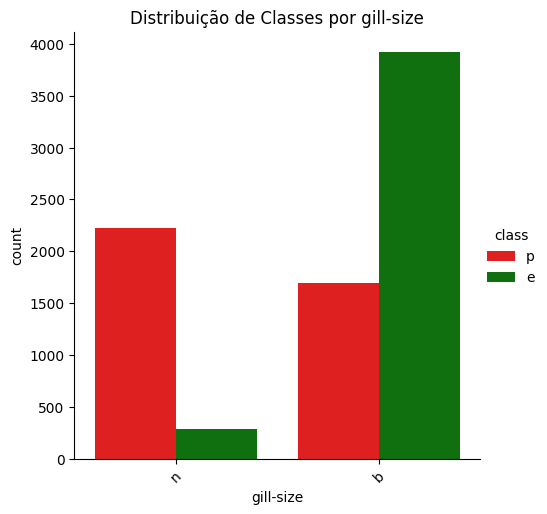

<Figure size 1000x500 with 0 Axes>

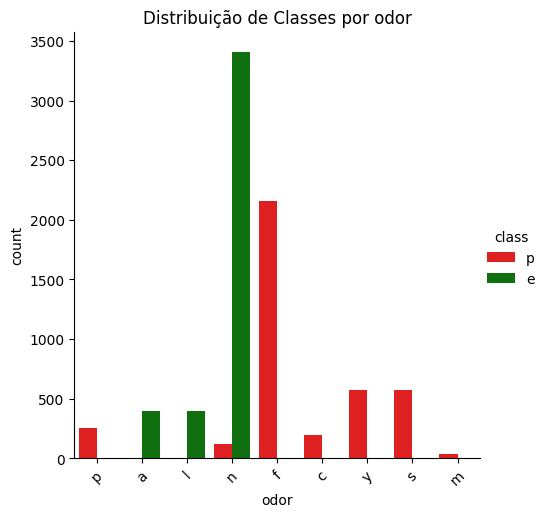


 Boxplot dos Atributos por Classe 



<Figure size 1000x500 with 0 Axes>

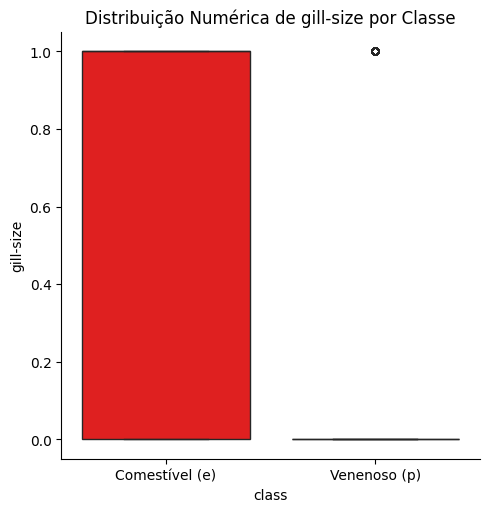

<Figure size 1000x500 with 0 Axes>

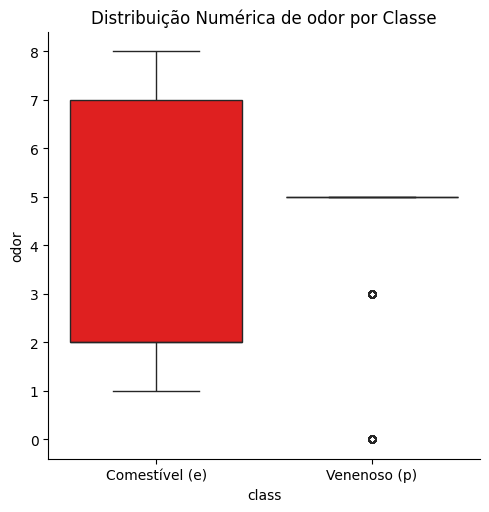

In [21]:
atributos_analise = ['gill-size', 'odor']  # Exemplo com dois atributos que aparentemente podem influenciar o target

# Criando DataFrame codificado para análise
df_encoded = df_imputed.copy()
for col in df_encoded.columns:
    if col != 'class':
        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# e) Histograma
print("\n=== Parte 3e: Distribuição das Classes por Atributo (Countplot) ===")
for atributo in atributos_analise:
    plt.figure(figsize=(10, 5))
    sns.catplot(data=df_imputed, x=atributo, hue='class', kind='count', palette={'e': 'green', 'p': 'red'})
    plt.title(f'Distribuição de Classes por {atributo}')
    plt.xticks(rotation=45)
    plt.show()

# f) Boxplot dos atributos
print("\n Boxplot dos Atributos por Classe \n")
for atributo in atributos_analise:
    plt.figure(figsize=(10, 5))
    sns.catplot(data=df_encoded, x='class', y=atributo, hue='class', kind='box', palette={'e': 'green', 'p': 'red'},legend=False
    )
    plt.title(f'Distribuição Numérica de {atributo} por Classe')
    plt.xticks(ticks=[0, 1], labels=['Comestível (e)', 'Venenoso (p)'])
    plt.show()

## Parte 4: Treinamento e avaliação da regressão logística

g) Aplique o modelo de regressão logística ao *dataset Mushroom*. Para isso, comente as escolhas metodológicas e de hiperparâmetros. Mostre, então, a matriz de confusão para o classificador considerando o conjunto de teste, bem como os valores de algumas métricas de desempenho (tanto globais quanto por classe). Para deixar mais completo o exercício, apresente esses resultados para três configurações distintas e significativas do modelo (e.g., ao variar o coeficiente de regularização $C$).

h) Apresente a curva ROC e o valor da área (AUC). Registre, por fim, as principais observações a respeito do desempenho geral da regressão logística.
- Consultar: https://scikit-learn.org/stable/api/sklearn.metrics.html




Parâmetros do modelo: 
[[ 0.9875813  -0.06119183 -0.37962421 -0.56584244 -0.22464233  1.27035505
   0.58205726  0.3323997  -0.87966125  0.14197785 -0.07322562 -0.45915494
   0.74837329 -0.64765385 -0.47472596  0.10916549 -0.85977926  0.01279403
   4.03922603  3.65691446 -1.66927777  0.40742439 -4.15510472  2.6645237
   1.05972603  1.03704002  0.51660871 -2.45004036  3.35272635 -0.69771437
  -0.13458176  0.03142387 -0.65514418 -0.76425951 -0.23601102 -0.57992859
   0.8979557  -0.15011582 -0.33302818  0.17502535 -0.70896242 -2.037146
   0.1997434  -1.4845444   1.46158412 -0.84759896  0.41398345  0.54833246
   0.26552111  1.1738995   0.40742439 -0.74687106 -0.28493604  0.01712933
  -0.74114501  0.48085071 -0.16624754  0.72250074  0.40742439 -0.68406785
  -0.27119729 -0.59168557 -0.74114501  0.55039761 -0.0499846   1.1065895
  -0.31882316  0.05171107  0.72250074 -0.26626377 -0.10809382 -2.25607706
   0.93711057  0.40742439 -0.14412375  1.01815811 -1.7475502  -2.06003094
  -0.20646323  4.92

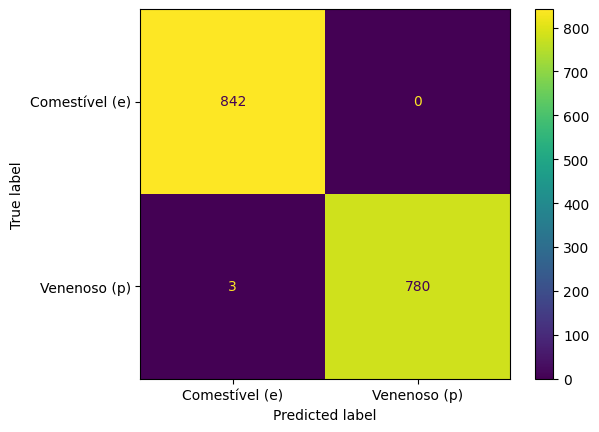

<Figure size 800x600 with 0 Axes>

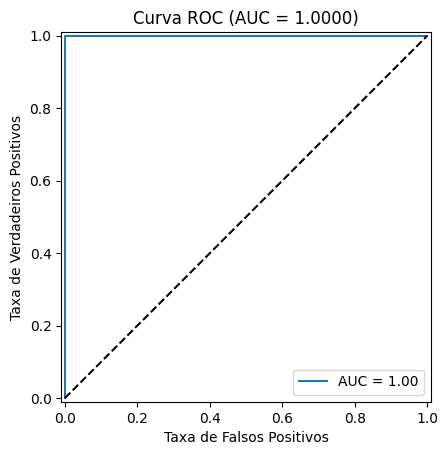

In [23]:

# g) Treinamento e análise do modelo de regressão logística

class_names = ['Comestível (e)', 'Venenoso (p)']
lr_model = LogisticRegression(penalty='l2')

#Treinamento
lr_model.fit(X_train,y_train)

#Conferindo os parâmetros do modelo
print(f'Parâmetros do modelo: \n{lr_model.coef_}')
print(f'Classes: \n{lr_model.classes_}')

#Aplicando a regressão logística sobre o conjunto de teste e obtendo os rótulos estimados
y_pred_test = lr_model.predict(X_test)

""" Obtém a matriz de confusão e outras métricas de desempenho no conjunto de teste """
confmat = confusion_matrix(y_true=y_test,
                            y_pred=y_pred_test)

ConfusionMatrixDisplay(confmat,display_labels=class_names).plot()

print(classification_report(y_true=y_test,
                            y_pred=y_pred_test,
                            target_names=class_names))

'''F1-score'''
print(f"F1-score no conjunto de teste: {f1_score(y_true=y_test,y_pred=y_pred_test,average='macro'):.4f} \n")

'''Acurácia Balanceada'''
balanced_acc = balanced_accuracy_score(y_test, y_pred_test)
print(f"Acurácia Balanceada: {balanced_acc:.4f}")

'''Curva ROC'''
y_proba = lr_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# h) Plotando a Curva ROC
plt.figure(figsize=(8, 6))
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()
plt.plot([0, 1], [0, 1], 'k--')
plt.title(f'Curva ROC (AUC = {roc_auc:.4f})')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.show()

''' Aparentemente, a regressão logística foi espantosamente boa, que até me leva crer que houve algum erro no meio do caminho...
    As métricas foram extremamente perto de valores confiáveis, e a divisão dos treinos-testes foi adequada 80-20. Certamente, o fato de
    ter um dataset bem balanceado contribuiu para que houvesse um bom aprendizado de máquina. A acurácia balanceada foi muito boa, e só houveram
    3 erros (classificou 3 comestíveis como venenosos, o que seria fatal rs). É realmente bem espantoso obter métricas tão boas, o que me leva a crer que certamente
    cometi um erro em algum dos passos (provavelmente parte 3). Entretanto, seguindo o material do scikit learn, e o exemplo de solução fornecido na aula 02, aparentemente parecia que o processo
    de aprendizagem foi bem estruturado, iniciando ao optar por utilizar o OneHotEncoding, ao invés de Encoders tradicionais para Multi-classe, que potencialmente poderiam
    causar maior grau de erro, e inputando valores faltantes pela moda, que é uma métrica de análise mais robusta que a média (sensível);
    Por fim, observa-se que o odor pungente (odor = p) e  espaço entre as guelras são bem determinantes na hora de verificar se o cogumelo é venenoso (p) ou comestível (e). '''
